In [2]:
from pandas import DataFrame
from sys import path

path.append('..')
from utils.data_enhancer import merged_data

In [36]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = merged_data('../data/playlist_new.json', '../data/video_details_new.json')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104 entries, 0 to 103
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   addedToPlaylistAt  103 non-null    datetime64[ns]
 1   videoId            104 non-null    object        
 2   videoPublishedAt   103 non-null    datetime64[ns]
 3   isPaid             104 non-null    int64         
 4   isSolutions        104 non-null    int64         
 5   isSession          104 non-null    int64         
 6   sessionNo          34 non-null     float64       
 7   taskNo             25 non-null     float64       
 8   sessionName        104 non-null    object        
 9   linkInVideo        99 non-null     object        
 10  videoTimestamp     61 non-null     object        
 11  categoryId         103 non-null    float64       
 12  commentCount       103 non-null    float64       
 13  duration           104 non-null    int64         
 14  likeCount 

### Note about the Dataset:

This dataset contains all the video present in Youtube playlist of **DSMP cousrse by CampusX**. In this dataset **1 video** not available because it is deleted from the Youtube (that's what youtube api says) `videoId='iOzA5Q_ZyFo'`.

> The course is running while performing this analysis.

- `videoId` is ID of Youtube video.

#### Info from API

- `addedToPlaylist` contains the datetime, when the is added the DSMP youtube playlist.
- `videoPublishedAt` contains the datetime referring when the video is published on Youtube.
- `categoryId` same for all videos `27`.
- `commentCount, viewCount, likeCount` _yeah toh pata he hoga_.
- `duration` of the video in **minutes**.

#### Info from Title

- `sessionName` refer to name of the session or video.
- `isPaid` referes to paid video as 1 and non-paid video as 0. `Category(0, 1)`
- `isSolutions` refers to **Task Solutions** video. `Category(0, 1)`
- `isSession` refers that video is a Free or Paid session of course. This course contains some other category of videos also like `'announcement videos', 'old videos'` etc. `Category(0, 1)`
- `taskNo` contains the `Task Number` from the title of the video.
- `sessionNo` contains the `Session Number` from the title of the video.

#### Info from Description

- `linkInVideo` contains a `list of URLs` present in the video's description.
- `videoTimeStamp` contains the timestamps provided in the decription.


In [10]:
# Drop the unavialble video
drop_index = df.query('sessionName=="Deleted video"').index
df.drop(index=drop_index, inplace=True)

<AxesSubplot: xlabel='isSession'>

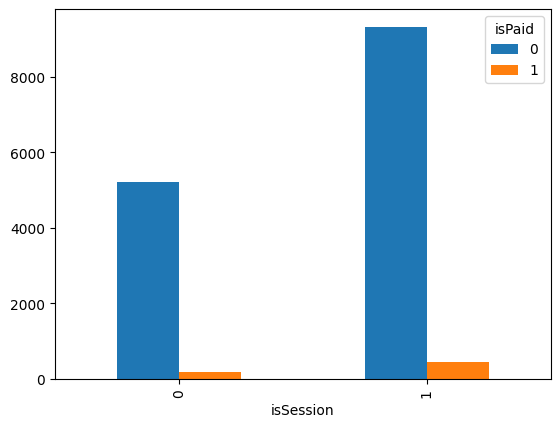

In [58]:
df.pivot_table('likeCount', index='isSession', columns='isPaid', aggfunc='sum').plot(kind='bar')

In [ ]:
# ndf = df.query('isSolutions==1')[['sessionName', 'linkInVideo']]

# ndf['linkInVideo'] = ndf['linkInVideo'].apply(lambda x: [i for i in x if 'colab' in i])

# for filename, notebooks in ndf.values:
#     if len(notebooks) > 1:
#         for i, nblink in enumerate(notebooks):
#             with open(f'{filename} {i}.ipynb', 'wb') as f:
#                 f.write(bytes(nblink, 'utf-8'))
#     else:
#         with open(f'{filename}.ipynb', 'wb') as f:
#             f.write(bytes(notebooks[0], 'utf-8'))
#     break